## Report z analizy danych

In [501]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

flights = pd.read_csv("data/flights.csv")
airports = pd.read_csv("data/airports.csv")
airlines = pd.read_csv("data/airlines.csv")
planes = pd.read_csv("data/planes.csv")
weather = pd.read_csv("data/weather.csv")


# flights.head()
# airports.head()
# airlines.head()
# planes.head()
# weather.head()



## TEST BAZY DANYCH

In [502]:
print("--- ŁADOWANIE DANYCH ---")
try:
    flights = pd.read_csv("data/flights.csv")
    airports = pd.read_csv("data/airports.csv")
    airlines = pd.read_csv("data/airlines.csv")
    planes = pd.read_csv("data/planes.csv")
    weather = pd.read_csv("data/weather.csv")
    print(" Wszystkie 5 plików załadowano pomyślnie z folderu 'data'!\n")
except FileNotFoundError as e:
    print(f" Błąd: Nie znaleziono pliku. Upewnij się, że masz folder 'data'. Szczegóły: {e}")
    exit()

--- ŁADOWANIE DANYCH ---
 Wszystkie 5 plików załadowano pomyślnie z folderu 'data'!



 WERYFIKACJA DUPLIKATÓW: AIRLINES 
Brak zduplikowanych wierszy (całkowitych).
Klucz główny ['carrier'] jest w pełni unikalny.
--------------------------------------------------
 WERYFIKACJA DUPLIKATÓW: PLANES 
Brak zduplikowanych wierszy (całkowitych).
Klucz główny ['tailnum'] jest w pełni unikalny.
--------------------------------------------------
 WERYFIKACJA DUPLIKATÓW: WEATHER 
Brak zduplikowanych wierszy (całkowitych).
BŁĄD KRYTYCZNY: Znaleziono 3 powtórzeń w kluczu głównym ['origin', 'year', 'month', 'day', 'hour']!
--------------------------------------------------
Anomalie dla : Flights


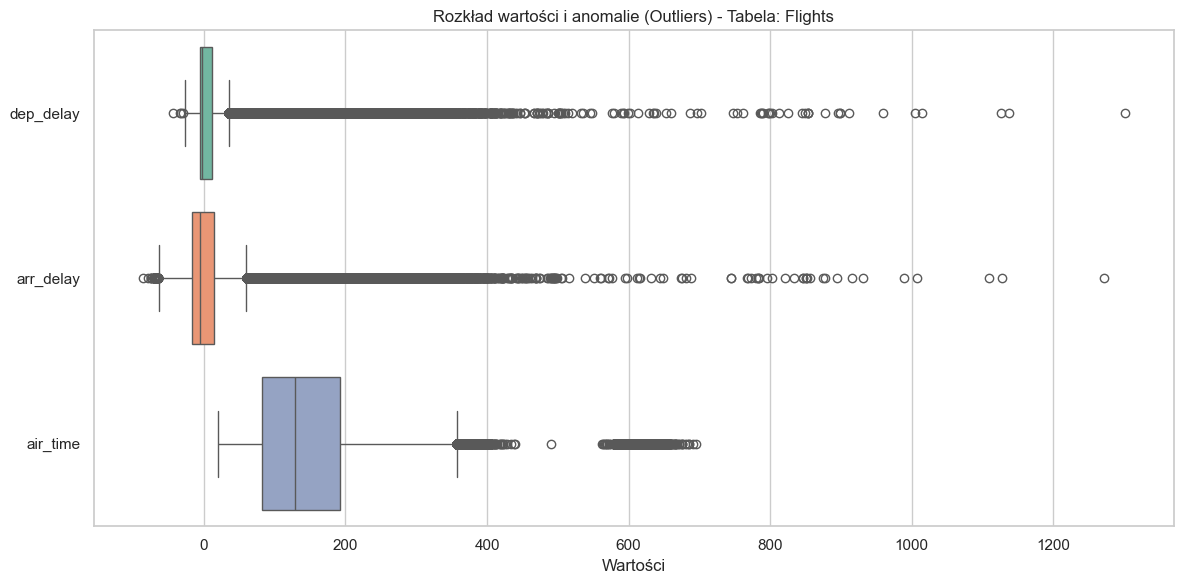

Anomalie dla : Weather


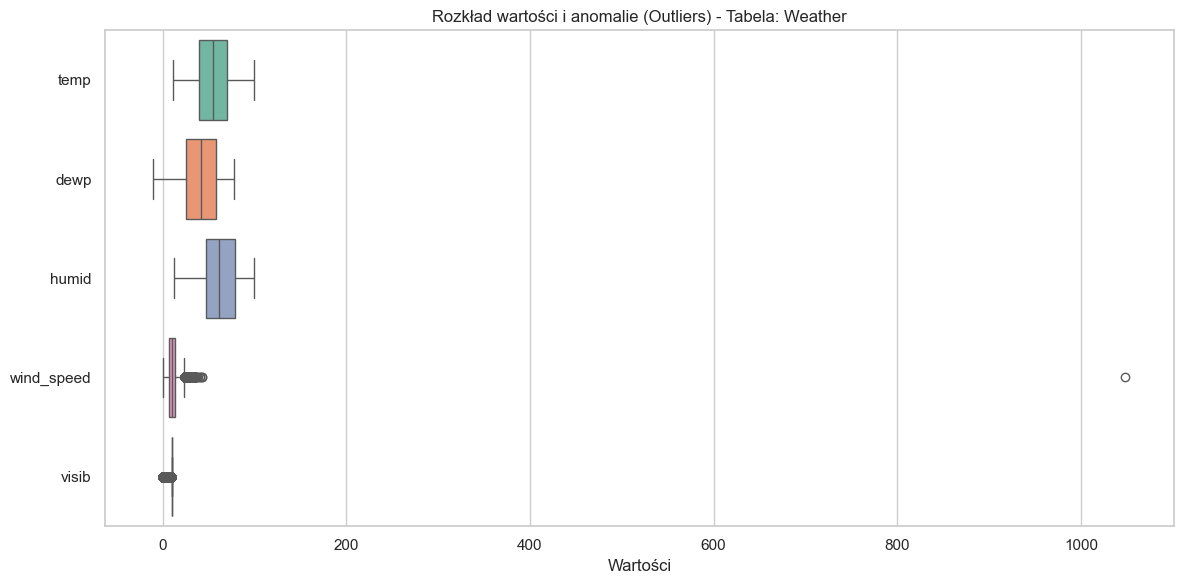

[FLIGHTS] Są braki 


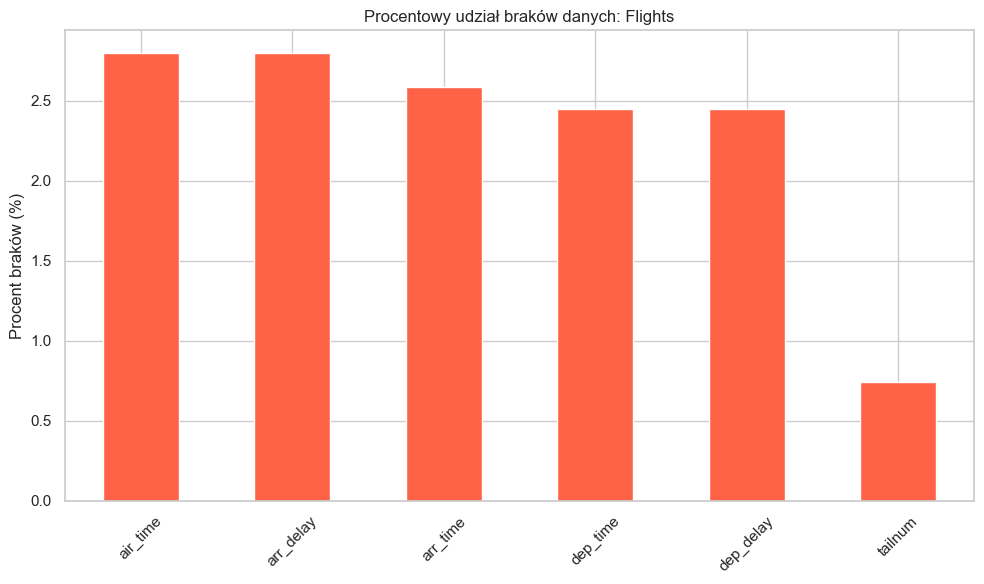

[AIRPORTS] Są braki 


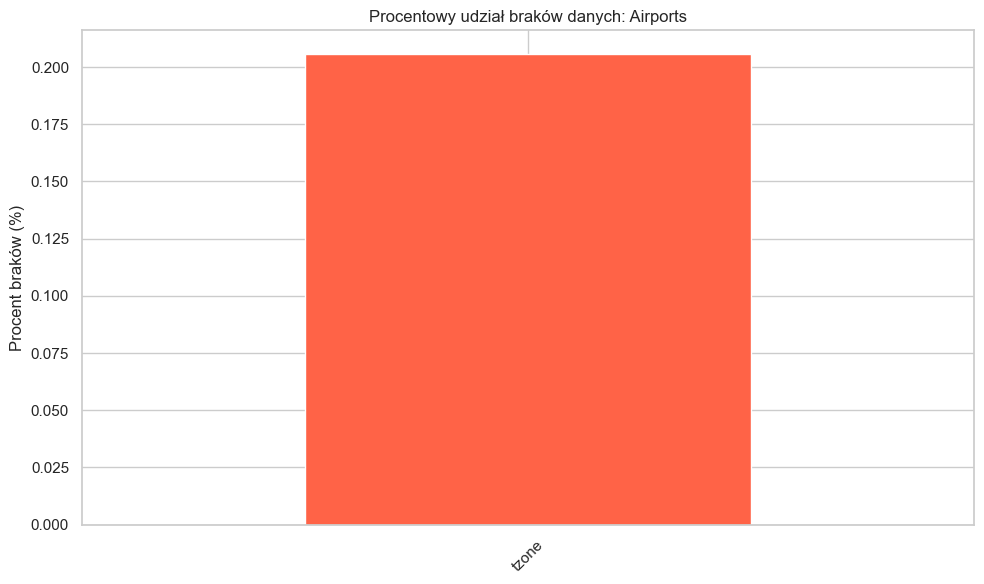

[AIRLINES] W tej tabeli nie ma NAN .
[PLANES] Są braki 


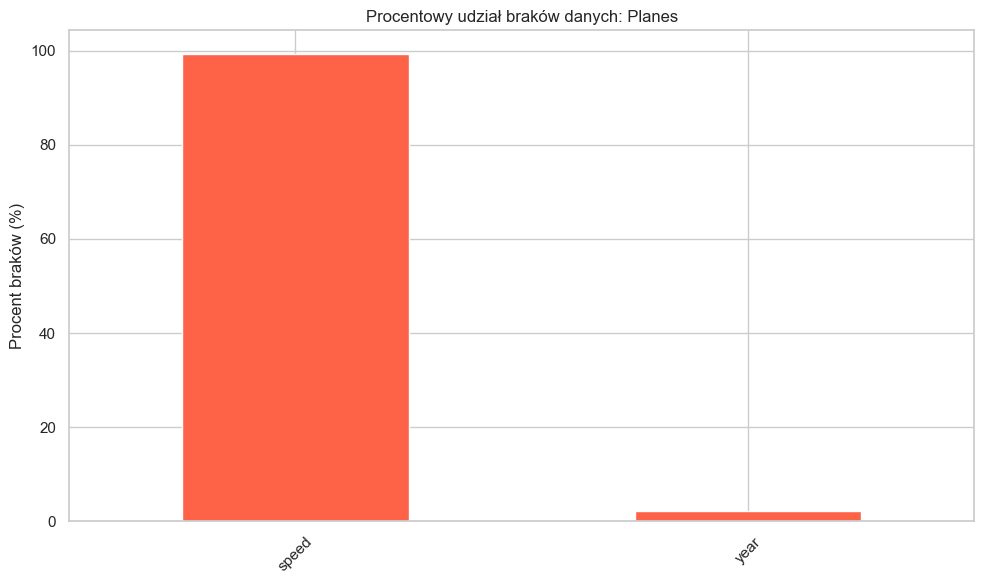

[WEATHER] Są braki 


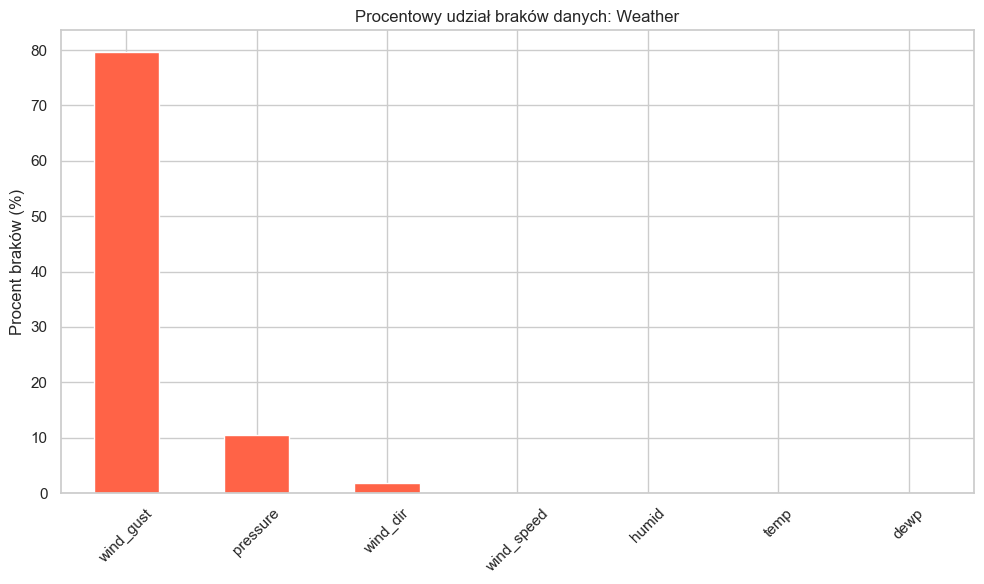

In [503]:
def sprawdz_duplikaty(df, nazwa_tabeli, klucz_glowny=None):
    """
    Sprawdza występowanie zduplikowanych wierszy w całej tabeli
    oraz opcjonalnie sprawdza unikalność wskazanego klucza głównego.
    """
    print(f" WERYFIKACJA DUPLIKATÓW: {nazwa_tabeli.upper()} ")

    # 1. Sprawdzanie duplikatów całych wierszy (identyczne wszystkie kolumny)
    duplikaty_wierszy = df.duplicated().sum()
    if duplikaty_wierszy > 0:
        print(f"OSTRZEŻENIE: Znaleziono {duplikaty_wierszy} w 100% zduplikowanych wierszy.")
    else:
        print("Brak zduplikowanych wierszy (całkowitych).")

    # 2. Sprawdzanie duplikatów w kluczu głównym (jeśli został podany)
    if klucz_glowny:
        # Obsługa kluczy złożonych (lista) lub pojedynczych (string)
        if isinstance(klucz_glowny, str):
            klucz_glowny = [klucz_glowny]

        duplikaty_klucza = df.duplicated(subset=klucz_glowny).sum()
        if duplikaty_klucza > 0:
            print(f"BŁĄD KRYTYCZNY: Znaleziono {duplikaty_klucza} powtórzeń w kluczu głównym {klucz_glowny}!")
        else:
            print(f"Klucz główny {klucz_glowny} jest w pełni unikalny.")
    print("-" * 50)


def wizualizuj_anomalie(df, nazwa_tabeli, kolumny_do_sprawdzenia):
    """
    Generuje wykresy pudełkowe (boxplots) dla wskazanych kolumn numerycznych,
    aby uwidocznić wartości odstające i błędy w danych.
    """
    print(f"Anomalie dla : {nazwa_tabeli}")

    kolumny_istniejace = [kol for kol in kolumny_do_sprawdzenia if kol in df.columns]
    if not kolumny_istniejace:
        print("Żadna ze wskazanych kolumn nie istnieje w tej tabeli.")
        return

    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")


    sns.boxplot(data=df[kolumny_istniejace], orient="h", palette="Set2")

    plt.title(f"Rozkład wartości i anomalie (Outliers) - Tabela: {nazwa_tabeli}")
    plt.xlabel("Wartości")
    plt.tight_layout()
    plt.show()

def sprawdz_i_rysuj(df, nazwa_tabeli):
    braki_procent = df.isna().mean() * 100
    braki_procent = braki_procent[braki_procent > 0].sort_values(ascending=False)
    if braki_procent.empty:
        print(f"[{nazwa_tabeli.upper()}] W tej tabeli nie ma NAN .")
        return


    print(f"[{nazwa_tabeli.upper()}] Są braki ")
    plt.figure(figsize=(10, 6))
    braki_procent.plot(kind='bar', color='tomato')
    plt.title(f"Procentowy udział braków danych: {nazwa_tabeli}")
    plt.ylabel("Procent braków (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
tabele_do_sprawdzenia = [
    (flights, "Flights"),
    (airports, "Airports"),
    (airlines, "Airlines"),
    (planes, "Planes"),
    (weather, "Weather")
]
sprawdz_duplikaty(airlines, "Airlines", klucz_glowny="carrier")
sprawdz_duplikaty(planes, "Planes", klucz_glowny="tailnum")
sprawdz_duplikaty(weather, "Weather", klucz_glowny=['origin', 'year', 'month', 'day', 'hour'])
wizualizuj_anomalie(flights, "Flights", ['dep_delay', 'arr_delay', 'air_time'])
wizualizuj_anomalie(weather, "Weather", ['temp','dewp', 'humid', 'wind_speed','visib'])
for df, nazwa in tabele_do_sprawdzenia:
    sprawdz_i_rysuj(df, nazwa)

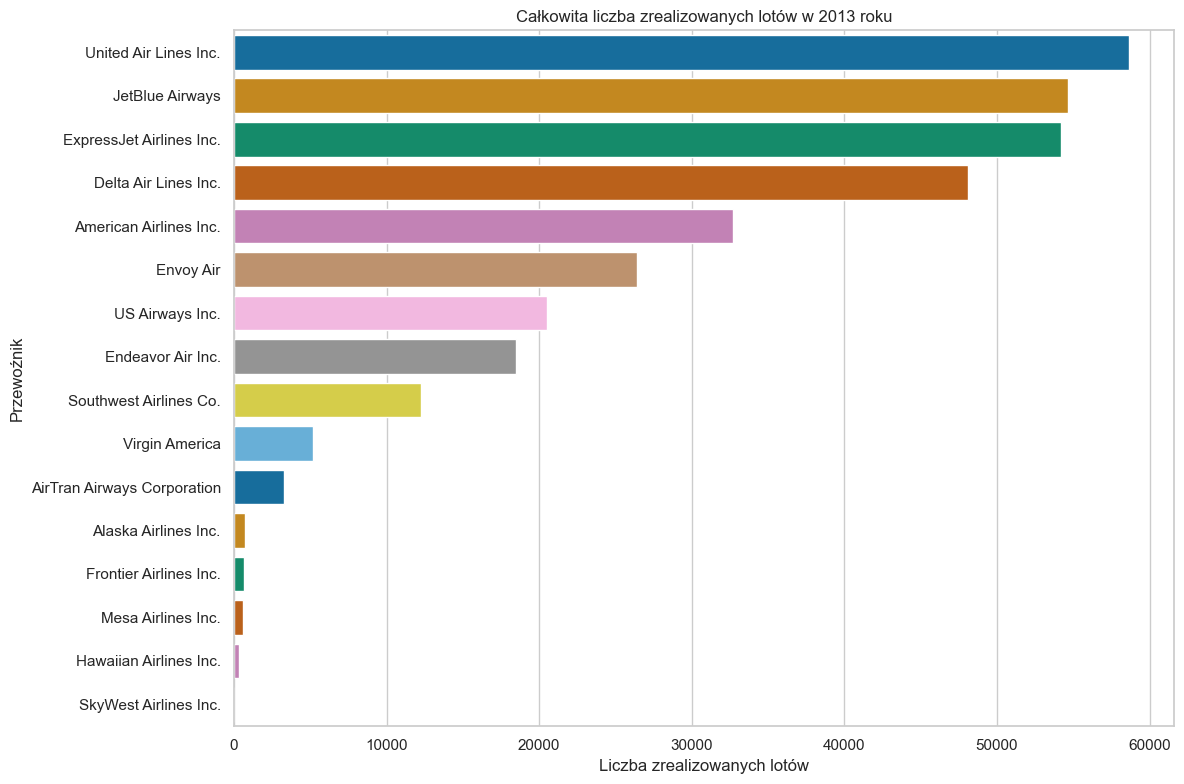

In [504]:
df = flights.merge(airlines.drop_duplicates(subset=['carrier']), on='carrier', how='left')

liczba_lotow = df['name'].value_counts().reset_index()
liczba_lotow.columns = ['Linia lotnicza', 'Liczba lotów']

# Konfiguracja i generowanie wykresu
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")
sns.barplot(
    data=liczba_lotow,
    x='Liczba lotów',
    y='Linia lotnicza',
    hue='Linia lotnicza',
    palette='colorblind',
    legend=False
)
plt.title("Całkowita liczba zrealizowanych lotów w 2013 roku")
plt.xlabel("Liczba zrealizowanych lotów")
plt.ylabel("Przewoźnik")
plt.tight_layout()
plt.show()

---

# Czyszczenie danych

## Krok 1: Standaryzacja (Usuwanie białych znaków)

In [505]:
# Usuwanie ukrytych spacji z kodów linii lotniczych
flights['carrier'] = flights['carrier'].astype(str).str.strip()
airlines['carrier'] = airlines['carrier'].astype(str).str.strip()

# Usuwanie ukrytych spacji z numerów rejestracyjnych samolotów
flights['tailnum'] = flights['tailnum'].astype(str).str.strip()
planes['tailnum'] = planes['tailnum'].astype(str).str.strip()

print("Klucze tekstowe (carrier, tailnum) zostały wyczyszczone z ukrytych białych znaków.")

Klucze tekstowe (carrier, tailnum) zostały wyczyszczone z ukrytych białych znaków.


## Krok 2: Wyodrębnienie lotów odwołanych i czyszczenie braków danych (`NaN`)

## Wizualizacja brakujących danych w 'flights'

<Axes: >

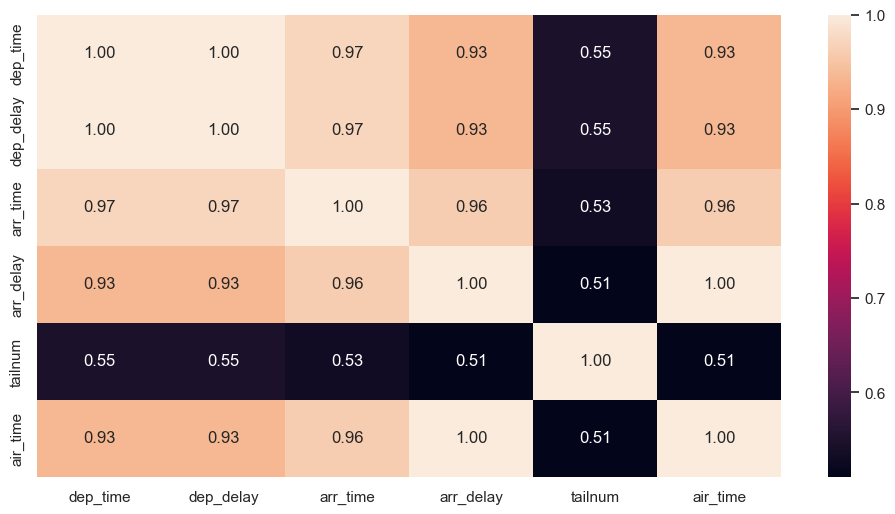

In [506]:
plt.figure(figsize=(12,6))
sns.heatmap(flights.loc[:, flights.isnull().any()].isnull().corr(), annot=True, fmt='.2f')

<Axes: >

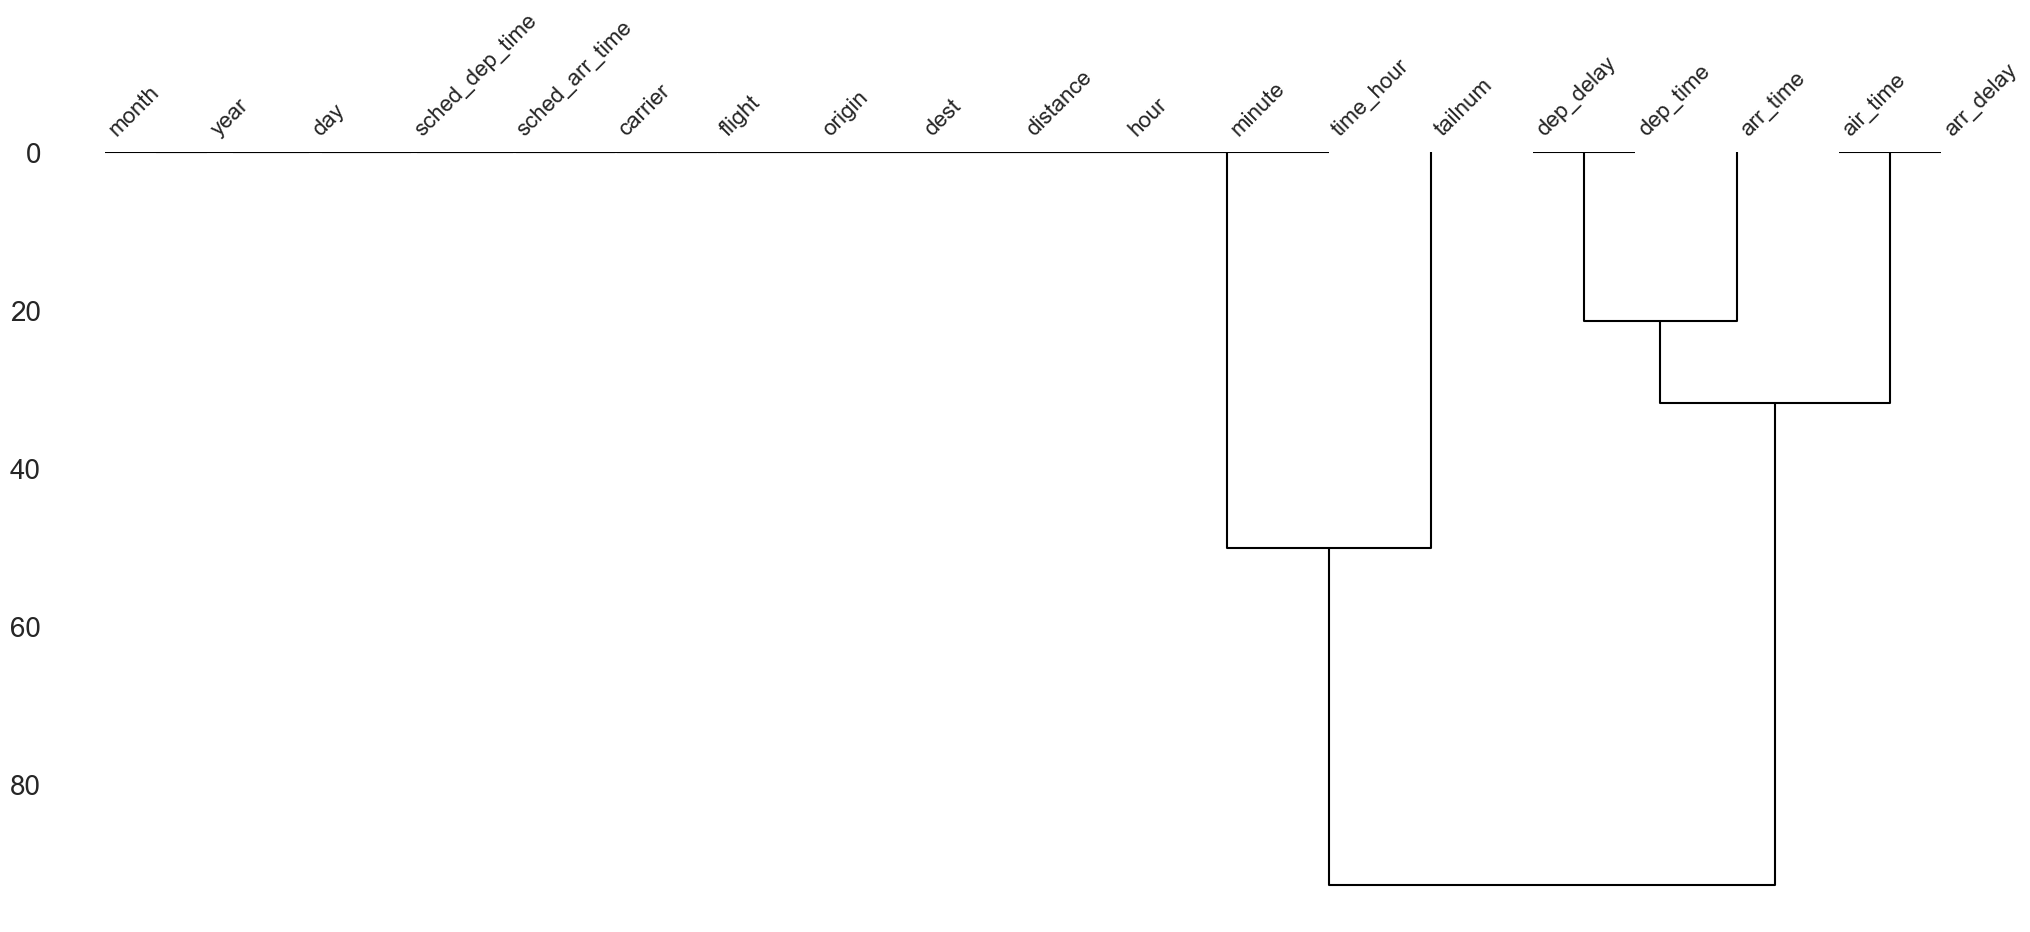

In [507]:
msno.dendrogram(flights)

# Sprawdzanie powodu braków w zmiennej 'tailnum'

In [508]:
pd.crosstab(flights['tailnum'].isna(),flights['dep_time'].isna())

dep_time,False,True
tailnum,,
False,328521,5743
True,0,2512


In [509]:
pd.crosstab(
    index=[flights['carrier'],flights['origin']],
    columns=flights['tailnum'].isna())

tailnum         False  True 
carrier origin              
9E      EWR      1200     68
        JFK     13844    807
        LGA      2372    169
AA      EWR      3474     13
        JFK     13752     31
        LGA     15419     40
AS      EWR       714      0
B6      EWR      6557      0
        JFK     42076      0
        LGA      6002      0
DL      EWR      4342      0
        JFK     20701      0
        LGA     23067      0
EV      EWR     43939      0
        JFK      1408      0
        LGA      8826      0
F9      LGA       682      3
FL      LGA      3260      0
HA      JFK       342      0
MQ      EWR      2276      0
        JFK      7192      1
        LGA     16927      1
OO      EWR         6      0
        LGA        26      0
UA      EWR     45652    435
        JFK      4490     44
        LGA      7837    207
US      EWR      4330     75
        JFK      2969     26
        LGA     12574    562
VX      EWR      1566      0
        JFK      3596      0
WN      EWR      6173     15
        LGA      6072     15
YV      LGA       601      0

### Z heatmapy widzimy że braki z jakimi mamy doczynienia ('dep_delay', 'arr_delay', 'air_time') to Missing Not At Random, a z tabeli korelacji widać że wszystkie braki w 'tailnum' wynikają z lotów które się nie odbyły i występują w schemacie MAR dla poszczególnych przewoźników, dlatego najlepszą praktyką będzie stworzenie czystego dataframe'a bez wyżej wspomnianych niepełnych rekordów i sprawdzenie czy pozostały jeszcze jakieś braki w naszym dataframe 'flights'

In [510]:
# 1. Oznaczenie lotów odwołanych
flights['is_cancelled'] = flights['dep_delay'].isna() | flights['arr_delay'].isna()
liczba_odwolanych = flights['is_cancelled'].sum()
print(f"Zidentyfikowano {liczba_odwolanych:,} odwołanych lotów w 2013 roku ({liczba_odwolanych/len(flights):.2%}).")

# 2. Pozotałe loty , które nie zostały odwałne
flights_clean = flights.dropna(subset=['dep_delay', 'arr_delay', 'air_time']).copy()

print(f"Liczba zrealizowanych lotów gotowych do analizy opóźnien: {len(flights_clean):,}")

Zidentyfikowano 9,430 odwołanych lotów w 2013 roku (2.80%).
Liczba zrealizowanych lotów gotowych do analizy opóźnien: 327,346


In [511]:
flights_clean.isna().sum()

year              0
month             0
day               0
dep_time          0
sched_dep_time    0
dep_delay         0
arr_time          0
sched_arr_time    0
arr_delay         0
carrier           0
flight            0
tailnum           0
origin            0
dest              0
air_time          0
distance          0
hour              0
minute            0
time_hour         0
is_cancelled      0
dtype: int64

## Sprawdzanie braków w Planes

In [512]:
planes.isna().sum()

tailnum            0
year              70
type               0
manufacturer       0
model              0
engines            0
seats              0
speed           3299
engine             0
dtype: int64

In [513]:
planes['year'] = planes.groupby(['manufacturer','model'])['year'].transform(lambda x: x.fillna(x.median()))
planes.isna().sum()

tailnum            0
year              12
type               0
manufacturer       0
model              0
engines            0
seats              0
speed           3299
engine             0
dtype: int64

### Dla 12 wartości nie da się obliczyć mediany przy obecnym grupowaniu, dlatego niezbędne jest grupowanie po innych wartościach

In [514]:
planes['year'] = planes.groupby('manufacturer')['year'].transform(lambda x: x.fillna(x.median()))
planes.isna().sum()

tailnum            0
year               8
type               0
manufacturer       0
model              0
engines            0
seats              0
speed           3299
engine             0
dtype: int64

In [515]:
planes['year'] = planes.groupby('model')['year'].transform(lambda x: x.fillna(x.median()))
planes.isna().sum()

tailnum            0
year               3
type               0
manufacturer       0
model              0
engines            0
seats              0
speed           3299
engine             0
dtype: int64

In [516]:
planes['year'] = planes.groupby('engine')['year'].transform(lambda x: x.fillna(x.median()))
planes.isna().sum()

tailnum            0
year               0
type               0
manufacturer       0
model              0
engines            0
seats              0
speed           3299
engine             0
dtype: int64

### Sprawdzanie braków w Airports

In [517]:
airports[airports['tzone'].isna()]

,faa,name,lat,lon,alt,tz,dst,tzone
417,EEN,Dillant Hopkins Airport,72.270833,42.898333,149,-5,A,NaN
815,LRO,Mount Pleasant Regional-Faison Field,32.538700,-79.469700,12,-5,A,NaN
1434,YAK,Yakutat,59.301200,-139.393700,33,-9,A,NaN


### Imputacja braków 'tzone' w tabeli Airports

In [518]:
mapa_stref = airports[['tz','tzone']].dropna().drop_duplicates().sort_values(by=['tz'])
mapa_ujednolicona = airports.groupby('tz')['tzone'].first()
mapa_ujednolicona

tz
-10       Pacific/Honolulu
-9       America/Anchorage
-8     America/Los_Angeles
-7         America/Phoenix
-6         America/Chicago
-5        America/New_York
 8          Asia/Chongqing
Name: tzone, dtype: str

In [519]:
airports['tzone'] = airports['tzone'].fillna(airports['tz'].map(mapa_ujednolicona))

In [520]:
airports[airports['faa'].isin(['EEN','LRO','YAK'])]

,faa,name,lat,lon,alt,tz,dst,tzone
417,EEN,Dillant Hopkins Airport,72.270833,42.898333,149,-5,A,America/New_York
815,LRO,Mount Pleasant Regional-Faison Field,32.538700,-79.469700,12,-5,A,America/New_York
1434,YAK,Yakutat,59.301200,-139.393700,33,-9,A,America/Anchorage


In [521]:
airports.isna().sum()

faa      0
name     0
lat      0
lon      0
alt      0
tz       0
dst      0
tzone    0
dtype: int64

## Wizualizacja braków w  Weather

In [522]:
weather['origin'].where(weather['pressure'].isna()).value_counts()

origin
LGA    963
EWR    935
JFK    831
Name: count, dtype: int64

### Powyżej widzimy równomierny rozkład braków na wszystkich lotniskach, dlatego sprawdzamy czy błędy pomiaru ciśnienia wynikają z innch wystepujących zjawisk pogodowych

In [523]:
df_kor = weather[['temp','dewp','humid','wind_speed','wind_dir','precip']].copy()
df_kor['pressure_isna'] = weather['pressure'].isna()
macierz_korelacji = df_kor.corr()

<Axes: ylabel='None'>

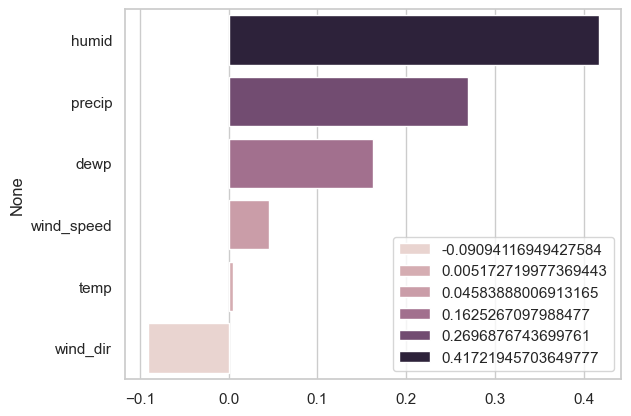

In [524]:
wektor = macierz_korelacji['pressure_isna'].sort_values(ascending=False).drop('pressure_isna')
sns.barplot(x=wektor.values, y=wektor.index, hue=wektor.values)

In [525]:
weather.isna().sum()

origin            0
year              0
month             0
day               0
hour              0
temp              1
dewp              1
humid             1
wind_dir        460
wind_speed        4
wind_gust     20778
precip            0
pressure       2729
visib             0
time_hour         0
dtype: int64

### Na wykresie widać, że problemy z pomiarem ciśnienia rosną wraz z rosnącą wilgotnością oraz opadami ('humid','precip'), stąd wiemy że braki z jakimi mamy doczynienia to braki Missing At Random
Używamy interpolacji aby uzupełnić brakujące dane sąsiednimi wartościami. Widzimy również pojedyncze brakujace wartości dla 'temp', 'dewp' oraz 'humid' sprawdzimy czy wszytkie 3 braki pochodzą z jednego pomiaru i również użyjemy interpolacji

In [526]:
weather[weather['temp'].isna()]

,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
5591,EWR,2013,8,22,9,NaN,NaN,NaN,320.0,12.65858,NaN,0.13,NaN,7.0,2013-08-22T13:00:00Z


In [527]:
weather['pressure'] = weather.groupby('origin')['pressure'].transform(lambda x: x.interpolate())
weather['wind_dir'] = weather.groupby('origin')['wind_dir'].transform(lambda x: x.interpolate())
weather[['temp','dewp','humid','wind_speed']] = weather.groupby('origin')[['temp','dewp','humid','wind_speed']].transform(lambda x: x.interpolate())

In [528]:
weather.isna().sum()

origin            0
year              0
month             0
day               0
hour              0
temp              0
dewp              0
humid             0
wind_dir          0
wind_speed        0
wind_gust     20778
precip            0
pressure          0
visib             0
time_hour         0
dtype: int64

## Krok 3: Analiza i usunięcie duplikatów w tabeli `weather`

### Podgladanie duplikatow

In [529]:
klucze_pogody = ['origin', 'year', 'month', 'day', 'hour']
maska_duplikatow = weather.duplicated(subset=klucze_pogody, keep=False)
duplikaty_wiersze = weather[maska_duplikatow].sort_values(by=klucze_pogody)
print(" --- ZNALEZIONE DUPLIKATY W TABELI WEATHER ---")
display(duplikaty_wiersze[['origin', 'month', 'day', 'hour', 'temp', 'wind_speed', 'precip']])

 --- ZNALEZIONE DUPLIKATY W TABELI WEATHER ---


,origin,month,day,hour,temp,wind_speed,precip
7318,EWR,11,3,1,51.98,6.90468,0.0
7319,EWR,11,3,1,50.00,5.75390,0.0
16023,JFK,11,3,1,53.96,9.20624,0.0
16024,JFK,11,3,1,51.98,6.90468,0.0
24729,LGA,11,3,1,55.04,9.20624,0.0
24730,LGA,11,3,1,53.96,8.05546,0.0


### Usuwanie kolumn, gdzie brakuje ponad 60% danych

In [530]:
planes = planes.drop(['speed'], axis=1)
weather = weather.drop(['wind_gust'], axis=1)

### Usuwanie duplikatów

In [531]:
przed_czyszczeniem = len(weather)
weather_clean = weather.drop_duplicates(subset=klucze_pogody, keep='first').copy()
po_czyszczeniu = len(weather_clean)

print(
    f"\nUsunięto {przed_czyszczeniem - po_czyszczeniu} zduplikowane wiersze. Klucz główny pogody jest teraz w pełni unikalny!")


Usunięto 3 zduplikowane wiersze. Klucz główny pogody jest teraz w pełni unikalny!


## Krok 4: Weryfikacja spójności fizycznej

In [532]:
# Sprawdzenie i odrzucenie wartości nielogicznych
przed_filtr = len(flights_clean)
flights_clean = flights_clean[(flights_clean['air_time'] > 0) & (flights_clean['distance'] > 0)]
po_filtr = len(flights_clean)

if przed_filtr != po_filtr:
    print(f"Usunięto {przed_filtr - po_filtr} wierszy z nielogicznym czasem lotu lub dystansem.")
else:
    print("Wszystkie czasy lotów i dystanse mają poprawne, dodatnie wartości.")

Wszystkie czasy lotów i dystanse mają poprawne, dodatnie wartości.


## Krok 5: Naprawa anomalii prędkości wiatru

In [533]:
# Zmina błędu  na Nan
weather_clean['wind_speed'] = np.where(weather_clean['wind_speed'] > 150, np.nan, weather_clean['wind_speed'])

# Nan uzupełnione medianom danych na temat wiatru w odpowiednim miesiącu i w odpowienidm rejonie
weather_clean['wind_speed'] = weather_clean['wind_speed'].fillna(
    weather_clean.groupby(['origin', 'month'])['wind_speed'].transform('median')
)

print("Anomalia wiatru została precyzyjnie zastąpiona medianą dla danego lotniska i miesiąca!")

Anomalia wiatru została precyzyjnie zastąpiona medianą dla danego lotniska i miesiąca!


---

# Podsumowanie preprocesingu

    #TODO
    Dopisać poodsumowanie

In [534]:
tabele_do_sprawdzenia = [
    (flights_clean, "Flights"),
    (airports, "Airports"),
    (airlines, "Airlines"),
    (planes, "Planes"),
    (weather_clean, "Weather")
]
for df, nazwa in tabele_do_sprawdzenia:
    sprawdz_i_rysuj(df, nazwa)

[FLIGHTS] W tej tabeli nie ma NAN .
[AIRPORTS] W tej tabeli nie ma NAN .
[AIRLINES] W tej tabeli nie ma NAN .
[PLANES] W tej tabeli nie ma NAN .
[WEATHER] W tej tabeli nie ma NAN .


## Eksport danych

In [535]:
# Zapisanie gotowych plików do dalszej analizy
flights_clean.to_csv("data/flights_clean.csv", index=False)
weather_clean.to_csv("data/weather_clean.csv", index=False)

# dataset do lotów odloanych
flights.to_csv("data/flights_with_cancelled.csv", index=False)

print(" Sukces! Wyczyszczone dane zostały zapisane w folderze 'data/'.")

 Sukces! Wyczyszczone dane zostały zapisane w folderze 'data/'.


# Łączenie tabel w jedną całość

In [536]:
print("--- TESTOWANIE RELACJI (MERGE) ---")
poczatkowa_liczba_lotow = len(flights_clean)
print(f"Baza wyjściowa: {poczatkowa_liczba_lotow} lotów.\n")

# TEST A: Loty + Linie lotnicze (Prosty klucz o tej samej nazwie)
print("Test A: Łączenie flights + airlines (po kluczu 'carrier')...")
airlines_clean = airlines.drop_duplicates(subset=['carrier'])
merged_airlines = flights_clean.merge(airlines_clean, on='carrier', how='left')

if len(merged_airlines) == poczatkowa_liczba_lotow:
    print(" Sukces ,  Liczba wierszy się zgadza.")
    print(f"   Doklejono kolumnę z nazwą linii: 'name'")
else:
    print(" Błąd! Liczba wierszy uległa zmianie.")
print("-" * 40)

# TEST B: Loty + Lotniska docelowe (Różne nazwy kluczy)
print("Test B: Łączenie flights + airports (po 'dest' i 'faa')...")
airports_clean = airports.drop_duplicates(subset=['faa'])
merged_airports = flights_clean.merge(airports_clean, left_on='dest', right_on='faa', how='left')

if len(merged_airports) == poczatkowa_liczba_lotow:
    print(" Sukces ,  Liczba wierszy się zgadza.")
    # dropujemy 'faa' bo to duplikat 'dest' po złączeniu
    merged_airports = merged_airports.drop(columns=['faa'])
    print(f"   Doklejono dane geograficzne lotnisk (lat, lon, alt itp.)")
else:
    print(" Błąd ,  Liczba wierszy uległa zmianie.")
print("-" * 40)

# TEST C: Loty + Samoloty (Prosty klucz o tej samej nazwie)
print("Test C: Łączenie flights + planes (po kluczu 'tailnum')...")
planes_clean = planes.drop_duplicates(subset=['tailnum'])
merged_planes = flights_clean.merge(planes_clean, on='tailnum', how='left')

if len(merged_planes) == poczatkowa_liczba_lotow:
    print(" Sukces ,  Liczba wierszy się zgadza.")
    print(f"   Doklejono dane techniczne maszyn (silniki, producent itp.)")
else:
    print(" Błąd! Liczba wierszy uległa zmianie.")
print("-" * 40)

# TEST D: Loty + Pogoda (Łączenie po 5 kolumnach naraz)
print("Test D: Łączenie flights + weather (wielokrotny klucz)...")
weather_clean = weather.drop_duplicates(subset=klucze_pogody)
merged_weather = flights_clean.merge(weather_clean, on=klucze_pogody, how='left')

if len(merged_weather) == poczatkowa_liczba_lotow:
    print(" Sukces , Liczba wierszy się zgadza.")
    print(f"   Doklejono warunki meteo (temp, wind_speed, precip itp.)")
else:
    print(" Błąd , Liczba wierszy uległa zmianie.")
print("=" * 40)
print(" Skrypt zakończył działanie. Wszystko działa")

--- TESTOWANIE RELACJI (MERGE) ---
Baza wyjściowa: 327346 lotów.

Test A: Łączenie flights + airlines (po kluczu 'carrier')...
 Sukces ,  Liczba wierszy się zgadza.
   Doklejono kolumnę z nazwą linii: 'name'
----------------------------------------
Test B: Łączenie flights + airports (po 'dest' i 'faa')...
 Sukces ,  Liczba wierszy się zgadza.
   Doklejono dane geograficzne lotnisk (lat, lon, alt itp.)
----------------------------------------
Test C: Łączenie flights + planes (po kluczu 'tailnum')...
 Sukces ,  Liczba wierszy się zgadza.
   Doklejono dane techniczne maszyn (silniki, producent itp.)
----------------------------------------
Test D: Łączenie flights + weather (wielokrotny klucz)...
 Sukces , Liczba wierszy się zgadza.
   Doklejono warunki meteo (temp, wind_speed, precip itp.)
 Skrypt zakończył działanie. Wszystko działa


In [537]:
flights.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour,is_cancelled
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01T10:00:00Z,False
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01T10:00:00Z,False
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01T10:00:00Z,False
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01T10:00:00Z,False
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01T11:00:00Z,False


# Wizualizacja
do wizualizacji zjawisk oraz relacji zachodzących pomiędzy róznymi tabelami używamy tabel typu 'merged_...' z którymi możemy się zapoznać w komórce wyżej

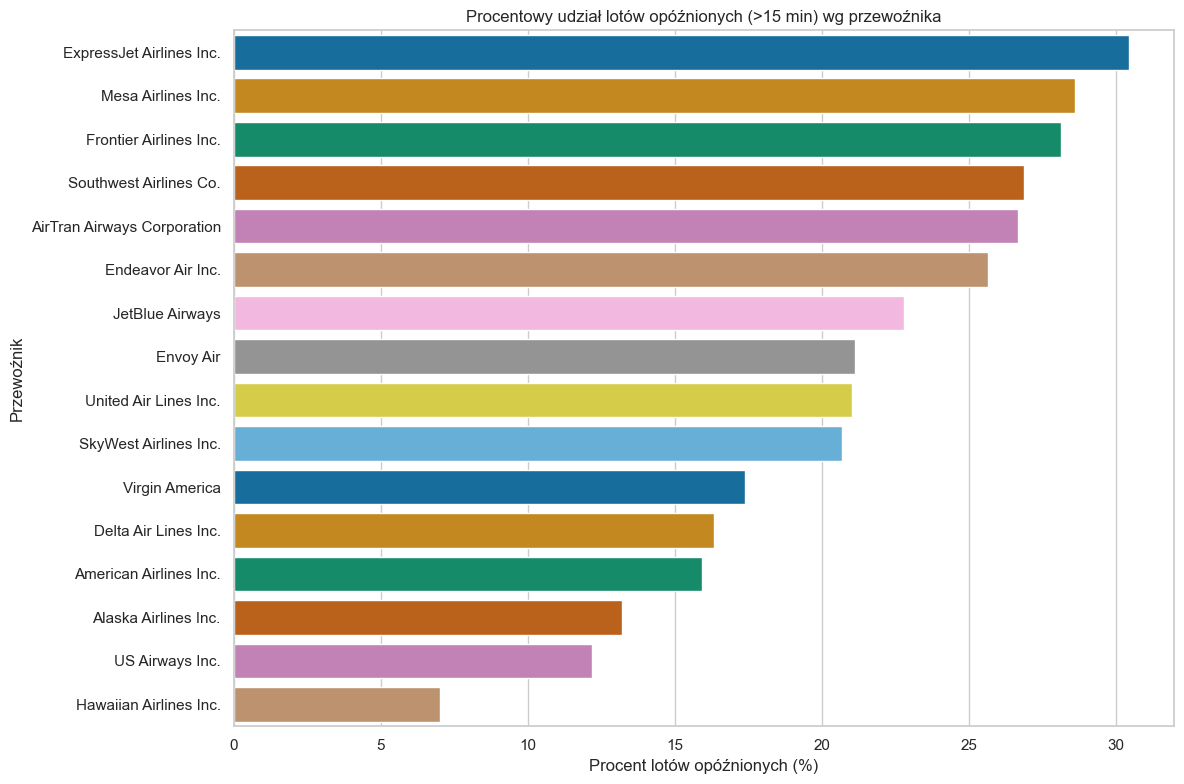

In [538]:

# Filtracja braków danych w kolumnie opóźnień
df = flights.dropna(subset=['dep_delay']).copy()
df = df.merge(airlines.drop_duplicates(subset=['carrier']), on='carrier', how='left')

# Utworzenie binarnej flagi opóźnienia (Powyżej 15 minut)
df['czy_opozniony'] = df['dep_delay'] > 15


procent_opoznien = df.groupby('name')['czy_opozniony'].mean() * 100
procent_opoznien = procent_opoznien.reset_index().sort_values(by='czy_opozniony', ascending=False)
procent_opoznien.columns = ['Linia lotnicza', 'Procent opóźnień (%)']


plt.figure(figsize=(12, 8))
sns.barplot(
    data=procent_opoznien,
    x='Procent opóźnień (%)',
    y='Linia lotnicza',
    hue='Linia lotnicza',
    palette='colorblind',
    legend=False
)
plt.title("Procentowy udział lotów opóźnionych (>15 min) wg przewoźnika")
plt.xlabel("Procent lotów opóźnionych (%)")
plt.ylabel("Przewoźnik")
plt.tight_layout()
plt.show()

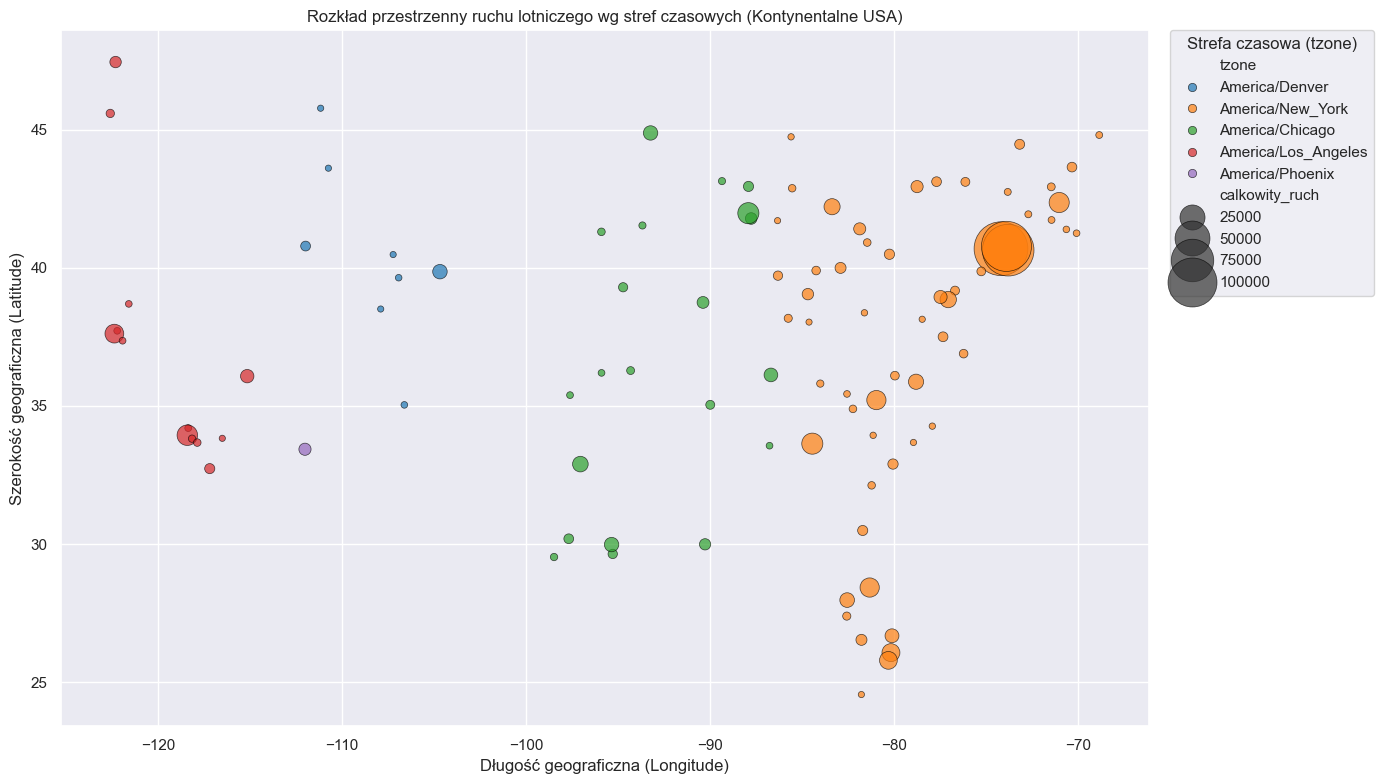

In [539]:


#  Agregacja ruchu lotniczego
odloty = flights['origin'].value_counts().reset_index()
odloty.columns = ['faa', 'liczba_odlotow']

przyloty = flights['dest'].value_counts().reset_index()
przyloty.columns = ['faa', 'liczba_przylotow']

#  Konsolidacja danych ze współrzędnymi i strefą czasową

baza_mapy = airports[['faa', 'name', 'lat', 'lon', 'tzone']].copy()
baza_mapy = baza_mapy.merge(odloty, on='faa', how='left').fillna({'liczba_odlotow': 0})
baza_mapy = baza_mapy.merge(przyloty, on='faa', how='left').fillna({'liczba_przylotow': 0})

baza_mapy['calkowity_ruch'] = baza_mapy['liczba_odlotow'] + baza_mapy['liczba_przylotow']
baza_mapy = baza_mapy[baza_mapy['calkowity_ruch'] > 0]

# Odcięcie Alaski i Hawajów
baza_mapy = baza_mapy[(baza_mapy['lon'] > -130) & (baza_mapy['lon'] < -60) & (baza_mapy['lat'] > 20) & (baza_mapy['lat'] < 50)]


plt.figure(figsize=(14, 8))
sns.set_theme(style="darkgrid")


sns.scatterplot(
    data=baza_mapy,
    x='lon',
    y='lat',
    size='calkowity_ruch',
    hue='tzone',
    sizes=(20, 1500),
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5,
    palette='tab10'
)

plt.title("Rozkład przestrzenny ruchu lotniczego wg stref czasowych (Kontynentalne USA)")
plt.xlabel("Długość geograficzna (Longitude)")
plt.ylabel("Szerokość geograficzna (Latitude)")


plt.legend(
    title='Strefa czasowa (tzone)',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.show()

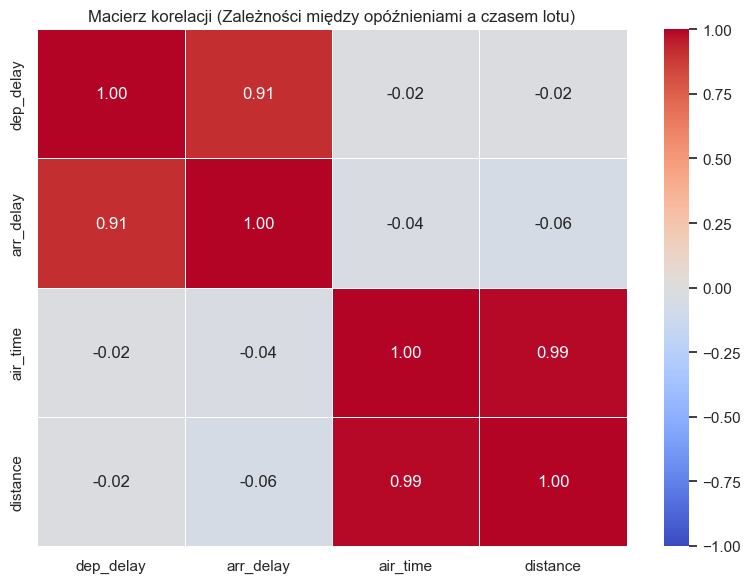

In [540]:
kolumny_numeryczne = ['dep_delay', 'arr_delay', 'air_time', 'distance']
df_num = flights[kolumny_numeryczne]

macierz_korelacji = df_num.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    macierz_korelacji,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1
)

plt.title("Macierz korelacji (Zależności między opóźnieniami a czasem lotu)")
plt.tight_layout()
plt.show()